# Roman Urdu Hate Speech Detection
## Notebook 04 (v2): MuRIL & TweetXLM-R Experiments

This notebook tests **two domain-matched transformers** as drop-in replacements:

| Model | Why it helps | Expected gain over XLM-R base |

- `google/muril-base-cased` **(MuRIL)** | Trained on 11 South-Asian languages **including their romanised forms** - Roman Urdu is in its pre-training data | +1–2% weighted F1 |
- `cardiffnlp/twitter-xlm-roberta-base` **(TweetXLM-R)** | XLM-R fine-tuned on 198M multilingual tweets - domain-matched for  60% Twitter data 

- Frozen bottom layers (prevents catastrophic forgetting)
- Linear warmup + decay scheduler
- R-Drop regularisation (α=4)
- Optimal threshold (tuned on val, not fixed at 0.5)
- FocalLoss + class weights + label smoothing
- Ensemble: best-transformer + BiGRU + CNNBiGRU


## 0. Install & Mount Drive

In [ ]:
# Run once per Colab session
!pip install transformers sentencepiece scikit-learn torch --quiet

import os, json, time, re, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Dataset as TorchDataset
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./results',     exist_ok=True)
print('Setup complete.')


Device: cuda
GPU: Tesla T4
Setup complete.


## 1. Experiment Configuration


In [ ]:
EXPERIMENT = 'muril'   

#  Per-model settings
CONFIGS = {
    'muril': {
        'model_name':   'google/muril-base-cased',
        'display_name': 'MuRIL',
        'max_len':      128,   # MuRIL handles longer seqs; Roman Urdu benefits from it
        'batch_train':  16,    # smaller batch — MuRIL is 12-layer like XLM-R
        'batch_eval':   32,
        'lr':           2e-5,
        'epochs':       8,
        'warmup_frac':  0.10,
        'freeze_layers': 6,    # freeze bottom 6 of 12 transformer layers
        'rdrop_alpha':  4.0,
        'label_smooth': 0.08,
        'focal_gamma':  2.0,
        'patience':     3,
    },
    'tweetxlm': {
        'model_name':   'cardiffnlp/twitter-xlm-roberta-base',
        'display_name': 'TweetXLM-R',
        'max_len':      64,    # tweets are short; matches the domain exactly
        'batch_train':  32,
        'batch_eval':   64,
        'lr':           2e-5,
        'epochs':       8,
        'warmup_frac':  0.10,
        'freeze_layers': 6,
        'rdrop_alpha':  4.0,
        'label_smooth': 0.08,
        'focal_gamma':  2.0,
        'patience':     3,
    },
}

CFG = CONFIGS[EXPERIMENT]
print(f'Experiment     : {CFG["display_name"]}  ({CFG["model_name"]})')
print(f'Max seq length : {CFG["max_len"]}')
print(f'Train batch    : {CFG["batch_train"]}')
print(f'Learning rate  : {CFG["lr"]}')
print(f'Epochs         : {CFG["epochs"]}')
print(f'Frozen layers  : {CFG["freeze_layers"]} (of 12)')


Experiment     : MuRIL  (google/muril-base-cased)
Max seq length : 128
Train batch    : 16
Learning rate  : 2e-05
Epochs         : 8
Frozen layers  : 6 (of 12)


## 2. Spelling Normalisation

Roman Urdu has no standard orthography. The same word appears in 5–15 different
spellings, wasting model vocabulary budget and creating OOV problems for any tokeniser.
We collapse common hate-speech terms to a single canonical form **before** tokenisation.


In [4]:
SPELL_NORM = [
    (r'ch[ou]ti+[ay]a?[n]?', 'chutiya'),
    (r'ch[ou]tya+',           'chutiya'),
    (r'ch[ou]tia+',           'chutiya'),
    (r'ma[dt][ae]r?[ch]+[ou]d', 'madarchod'),
    (r'mather?ch[ou]d',        'madarchod'),
    (r'mader?ch[ou]d',         'madarchod'),
    (r'ga?[nm]d[uo]+',         'gandu'),
    (r'ga?[nm]d[ao]o',         'gandu'),
    (r'hara+mi+',              'harami'),
    (r'ka?nja?ri+',            'kanjri'),
    (r'kanjr[iy]',             'kanjri'),
    (r'ba?kwa+s+',             'bakwas'),
    (r'kami+na+',              'kamina'),
    (r'kammi+na+',             'kamina'),
    (r'la+na+t+[i]*',          'lanat'),
    (r'la+[ae]na+t',           'lanat'),
    (r'bh?[ea]n+ch[ou]d',      'bhenchod'),
    (r'b[ey]?nch[ou]d',        'bhenchod'),
    (r'([a-z])\1{2,}',        r'\1\1'),   # haaaan -> haan
]

SPELL_PATTERNS = [(re.compile(p, re.IGNORECASE), r) for p, r in SPELL_NORM]

def normalise_text(text):
    if not isinstance(text, str):
        return text
    text = text.lower().strip()
    for pattern, replacement in SPELL_PATTERNS:
        text = pattern.sub(replacement, text)
    return text

# Quick sanity check
tests = [
    ('chutya harami hai ye',  'chutiya harami hai ye'),
    ('matherchod banda hai',  'madarchod banda hai'),
    ('haaaan yaaaaar',        'haan yaar'),
]
print('Normalisation tests:')
for inp, expected in tests:
    result = normalise_text(inp)
    status = '✓' if result == expected else f'✗ GOT: {result}'
    print(f'  {inp!r:35} → {result!r:25} [{status}]')
print('Spelling normaliser ready.')


Normalisation tests:
  'chutya harami hai ye'              → 'chutiya harami hai ye'   [✓]
  'matherchod banda hai'              → 'madarchod banda hai'     [✓]
  'haaaan yaaaaar'                    → 'haan yaar'               [✓]
Spelling normaliser ready.


## 3. Load Data & Artefacts

In [9]:
with open('/content/artefacts/config.json') as f:
    CONFIG = json.load(f)

VOCAB_SIZE       = CONFIG['vocab_size']
CHAR_VOCAB_SIZE  = CONFIG['char_vocab_size']
PAD_IDX          = CONFIG['pad_idx']
CHAR_PAD_IDX     = CONFIG['char_pad_idx']
MAX_SEQ_LEN      = 32          # 83% of texts fit in ≤32 word tokens
CHAR_MAX_LEN     = CONFIG['char_max_len']
NUM_FINE_CLASSES = CONFIG['num_fine_classes']

EMBED_DIM    = np.load('/content/artefacts/embed_matrix.npy', mmap_mode='r').shape[1]
embed_matrix = np.load('/content/artefacts/embed_matrix.npy')
print(f'EMBED_DIM: {EMBED_DIM}  |  embed_matrix: {embed_matrix.shape}')

with open('/content/artefacts/word2idx.json',  encoding='utf-8') as f: word2idx  = json.load(f)
with open('/content/artefacts/char2idx.json')  as f: char2idx  = json.load(f)
with open('/content/artefacts/label2idx.json') as f: label2idx = json.load(f)
with open('/content/artefacts/idx2label.json') as f:
    idx2label = {int(k): v for k, v in json.load(f).items()}

X_train      = np.load('/content/artefacts/X_train.npy')[:, :MAX_SEQ_LEN]
X_train_char = np.load('/content/artefacts/X_train_char.npy')
y_train      = np.load('/content/artefacts/y_train.npy')
y_train_fg   = np.load('/content/artefacts/y_train_fg.npy')

X_val        = np.load('/content/artefacts/X_val.npy')[:, :MAX_SEQ_LEN]
X_val_char   = np.load('/content/artefacts/X_val_char.npy')
y_val        = np.load('/content/artefacts/y_val.npy')
y_val_fg     = np.load('/content/artefacts/y_val_fg.npy')

X_test       = np.load('/content/artefacts/X_test.npy')[:, :MAX_SEQ_LEN]
X_test_char  = np.load('/content/artefacts/X_test_char.npy')
y_test       = np.load('/content/artefacts/y_test.npy')
y_test_fg    = np.load('/content/artefacts/y_test_fg.npy')

df_train = pd.read_csv('/content/data/train.csv')
df_val   = pd.read_csv('/content/data/val.csv')
df_test  = pd.read_csv('/content/data/test.csv')

train_texts = [normalise_text(t) for t in df_train['text_clean'].tolist()]
val_texts   = [normalise_text(t) for t in df_val['text_clean'].tolist()]
test_texts  = [normalise_text(t) for t in df_test['text_clean'].tolist()]

n_not_hate  = (y_train == 0).sum()
n_hate      = (y_train == 1).sum()
class_ratio = n_not_hate / n_hate
print(f'Class ratio: {n_not_hate:,} not_hate : {n_hate:,} hate = {class_ratio:.2f}:1')
print(f'Optimal classification threshold ≈ {1/(1+class_ratio):.2f}')
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

EMBED_DIM: 300  |  embed_matrix: (34043, 300)
Class ratio: 63,515 not_hate : 26,470 hate = 2.40:1
Optimal classification threshold ≈ 0.29
Train: (89985, 32) | Val: (14833, 32) | Test: (14833, 32)


## 4. Loss Functions, Evaluation & Utilities

In [10]:
ALL_RESULTS = {}

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, class_weights=None, label_smoothing=0.08, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.class_weights  = class_weights
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, weight=self.class_weights,
                              label_smoothing=self.label_smoothing, reduction='none')
        p_t = F.softmax(logits, dim=1).gather(1, targets.unsqueeze(1)).squeeze(1)
        loss = ((1 - p_t) ** self.gamma) * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


def make_class_weights(y, num_classes=2, device=DEVICE):
    counts  = np.bincount(y, minlength=num_classes).astype(float)
    weights = counts.sum() / (num_classes * counts)
    weights = weights / weights.mean()
    print(f'  Class weights: {dict(enumerate(weights.round(3)))}')
    return torch.tensor(weights, dtype=torch.float32, device=device)


def evaluate_predictions(y_true, y_pred, model_name, verbose=True):
    metrics = {
        'accuracy':         round(accuracy_score(y_true, y_pred), 4),
        'f1_weighted':      round(f1_score(y_true, y_pred, average='weighted'), 4),
        'f1_hate':          round(f1_score(y_true, y_pred, pos_label=1, average='binary'), 4),
        'f1_not_hate':      round(f1_score(y_true, y_pred, pos_label=0, average='binary'), 4),
        'precision':        round(precision_score(y_true, y_pred, average='weighted'), 4),
        'recall':           round(recall_score(y_true, y_pred, average='weighted'), 4),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    ALL_RESULTS[model_name] = metrics
    if verbose:
        print(f'\n=== {model_name} ===')
        for k, v in metrics.items():
            if k != 'confusion_matrix': print(f'  {k:<18}: {v}')
        print(classification_report(y_true, y_pred, target_names=['not_hate', 'hate']))
    return metrics


def find_optimal_threshold(probs, y_true, lo=0.2, hi=0.5, steps=30):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(lo, hi, steps):
        preds = (probs[:, 1] >= t).astype(int)
        f1 = f1_score(y_true, preds, average='weighted', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['not_hate', 'hate'], yticklabels=['not_hate', 'hate'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.savefig(f'./results/cm_{model_name.replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()


def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    if history.get('train_loss') and any(v != 0 for v in history['train_loss']):
        axes[0].plot(history['train_loss'], label='Train', color=PALETTE[0])
        axes[0].plot(history['val_loss'],   label='Val',   color=PALETTE[1])
        axes[0].set_title(f'{model_name} — Loss'); axes[0].legend()
    else:
        axes[0].set_title(f'{model_name} — Loss (N/A)')
    axes[1].plot(history['train_f1'], label='Train', color=PALETTE[0])
    axes[1].plot(history['val_f1'],   label='Val',   color=PALETTE[1])
    axes[1].set_title(f'{model_name} — Weighted F1'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'./results/curves_{model_name.replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()


class EarlyStopping:
    def __init__(self, patience=5, mode='max', min_delta=1e-4):
        self.patience = patience; self.mode = mode; self.min_delta = min_delta
        self.best = -np.inf if mode == 'max' else np.inf
        self.counter = 0; self.stop = False
    def __call__(self, val):
        improved = (val > self.best + self.min_delta) if self.mode == 'max'                    else (val < self.best - self.min_delta)
        if improved:
            self.best = val; self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience: self.stop = True


print('Utilities ready.')


Utilities ready.


## 5. Datasets & DataLoaders

In [11]:
class HateSpeechDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class DualDataset(Dataset):
    def __init__(self, X_word, X_char, y, y_fg):
        self.X_word = torch.tensor(X_word, dtype=torch.long)
        self.X_char = torch.tensor(X_char, dtype=torch.long)
        self.y      = torch.tensor(y,      dtype=torch.long)
        self.y_fg   = torch.tensor(y_fg,   dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X_word[i], self.X_char[i], self.y[i], self.y_fg[i]


BATCH = 128

train_loader = DataLoader(HateSpeechDataset(X_train, y_train), batch_size=BATCH, shuffle=True,  num_workers=2)
val_loader   = DataLoader(HateSpeechDataset(X_val,   y_val),   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(HateSpeechDataset(X_test,  y_test),  batch_size=BATCH, shuffle=False, num_workers=2)

dual_train_loader = DataLoader(DualDataset(X_train, X_train_char, y_train, y_train_fg), batch_size=BATCH, shuffle=True,  num_workers=2)
dual_val_loader   = DataLoader(DualDataset(X_val,   X_val_char,   y_val,   y_val_fg),   batch_size=BATCH, shuffle=False, num_workers=2)
dual_test_loader  = DataLoader(DualDataset(X_test,  X_test_char,  y_test,  y_test_fg),  batch_size=BATCH, shuffle=False, num_workers=2)

print('DataLoaders ready.')


DataLoaders ready.


## 6. Embedding Helper & Training Engine 

- **R-Drop**: two forward passes per batch, KL-divergence penalty between them
- **Frozen embeddings**: FastText embeddings locked during training
- **Linear warmup + decay**: for all transformer models


In [12]:
def load_pretrained_embedding(embedding_layer, embed_matrix, freeze=True):
    with torch.no_grad():
        embedding_layer.weight.copy_(torch.tensor(embed_matrix, dtype=torch.float32))
        embedding_layer.weight[0] = 0.0
    embedding_layer.weight.requires_grad = not freeze
    status = 'FROZEN' if freeze else 'fine-tunable'
    print(f'  [fastText] Embedding {status}: {embed_matrix.shape}')


def rdrop_loss(logits1, logits2, labels, criterion, alpha=4.0):
    loss1 = criterion(logits1, labels)
    loss2 = criterion(logits2, labels)
    p1 = F.softmax(logits1, dim=1)
    p2 = F.softmax(logits2, dim=1)
    kl = F.kl_div(p1.log(), p2, reduction='batchmean') +          F.kl_div(p2.log(), p1, reduction='batchmean')
    return 0.5 * (loss1 + loss2) + alpha * 0.5 * kl


def get_linear_warmup_decay_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / max(1, warmup_steps)
        progress = float(step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 1.0 - progress)
    from torch.optim.lr_scheduler import LambdaLR
    return LambdaLR(optimizer, lr_lambda)


def evaluate_model(model, loader, criterion, mode='word'):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    with torch.no_grad():
        for batch in loader:
            if mode == 'word':
                x, labels = [b.to(DEVICE) for b in batch]
                logits = model(x)
            else:
                x, xc, labels, _ = [b.to(DEVICE) for b in batch]
                logits, _ = model(x, xc)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            probs = F.softmax(logits, dim=1)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    n = len(loader.dataset)
    avg_loss = total_loss / n
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, f1, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def train_model_v4(model, train_loader, val_loader, name,
                   max_epochs=20, lr=1e-3, patience=5,
                   mode='word', rdrop_alpha=4.0):
    model = model.to(DEVICE)
    cw        = make_class_weights(y_train)
    criterion = FocalLoss(gamma=2.0, class_weights=cw, label_smoothing=0.08)
    criterion_aux = nn.CrossEntropyLoss(ignore_index=-1)
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=lr, weight_decay=1e-2)
    total_steps  = max_epochs * len(train_loader)
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_linear_warmup_decay_scheduler(optimizer, warmup_steps, total_steps)
    scaler    = GradScaler(enabled=(DEVICE.type == 'cuda'))

    best_f1, best_ckpt = -np.inf, f'./checkpoints/{name}.pt'
    early_stop = EarlyStopping(patience=patience, mode='max')
    history = defaultdict(list)
    t_start = time.time()

    for epoch in range(1, max_epochs + 1):
        t_ep = time.time()
        model.train()
        tr_loss_sum, all_preds, all_labels_list = 0.0, [], []
        step = 0

        for batch in train_loader:
            optimizer.zero_grad()
            with autocast(enabled=(DEVICE.type == 'cuda')):
                if mode == 'word':
                    x, labels = [b.to(DEVICE) for b in batch]
                    l1 = model(x); l2 = model(x)
                    loss = rdrop_loss(l1, l2, labels, criterion, alpha=rdrop_alpha)
                    logits = l1
                else:
                    x, xc, labels, labels_fg = [b.to(DEVICE) for b in batch]
                    l1_main, l1_aux = model(x, xc)
                    l2_main, _      = model(x, xc)
                    loss_main = rdrop_loss(l1_main, l2_main, labels, criterion, alpha=rdrop_alpha)
                    mask = labels_fg != -1
                    loss_aux = criterion_aux(l1_aux[mask], labels_fg[mask]) if mask.sum() > 0                                else torch.tensor(0.0, device=DEVICE)
                    loss   = loss_main + 0.3 * loss_aux
                    logits = l1_main

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            scheduler.step()
            tr_loss_sum += loss.item() * labels.size(0)
            all_preds.extend(logits.argmax(1).cpu().detach().numpy())
            all_labels_list.extend(labels.cpu().numpy())

        tr_loss = tr_loss_sum / len(train_loader.dataset)
        tr_f1   = f1_score(all_labels_list, all_preds, average='weighted', zero_division=0)
        va_loss, va_f1, _, _, _ = evaluate_model(model, val_loader, criterion, mode)

        history['train_loss'].append(tr_loss)
        history['train_f1'].append(tr_f1)
        history['val_loss'].append(va_loss)
        history['val_f1'].append(va_f1)

        if va_f1 > best_f1:
            best_f1 = va_f1
            torch.save(model.state_dict(), best_ckpt)

        early_stop(va_f1)
        cur_lr = optimizer.param_groups[0]['lr']
        marker = ' ← best' if va_f1 == best_f1 else ''
        print(f'Ep {epoch:02d}/{max_epochs} | tr_f1={tr_f1:.4f} va_f1={va_f1:.4f} | '
              f'lr={cur_lr:.2e} | {time.time()-t_ep:.1f}s{marker}')
        if early_stop.stop:
            print(f'Early stopping at epoch {epoch}.')
            break

    print(f'Total: {(time.time()-t_start)/60:.1f} min | Best val F1: {best_f1:.4f}')
    return dict(history), best_ckpt, best_f1


print('Training engine ready.')


Training engine ready.


## 7. Baselines (LR + SVM)


=== LR+TFIDF ===
  accuracy          : 0.8949
  f1_weighted       : 0.8959
  f1_hate           : 0.8271
  f1_not_hate       : 0.9245
  precision         : 0.8976
  recall            : 0.8949
              precision    recall  f1-score   support

    not_hate       0.94      0.91      0.92     10470
        hate       0.80      0.85      0.83      4363

    accuracy                           0.89     14833
   macro avg       0.87      0.88      0.88     14833
weighted avg       0.90      0.89      0.90     14833



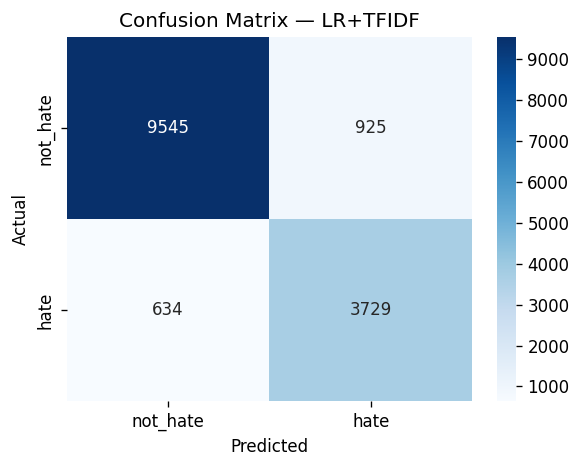


=== SVM+TFIDF ===
  accuracy          : 0.8931
  f1_weighted       : 0.8938
  f1_hate           : 0.8225
  f1_not_hate       : 0.9235
  precision         : 0.8949
  recall            : 0.8931
              precision    recall  f1-score   support

    not_hate       0.93      0.91      0.92     10470
        hate       0.80      0.84      0.82      4363

    accuracy                           0.89     14833
   macro avg       0.87      0.88      0.87     14833
weighted avg       0.89      0.89      0.89     14833



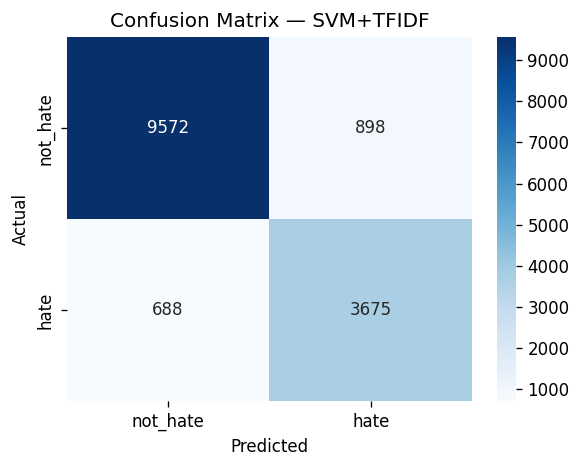

In [13]:
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=150000,
                               sublinear_tf=True, analyzer='word')),
    ('clf',   LogisticRegression(C=5.0, solver='saga', max_iter=1000,
                                  class_weight='balanced', n_jobs=-1))
])
lr_pipe.fit(train_texts, y_train)
y_pred_lr = lr_pipe.predict(test_texts)
evaluate_predictions(y_test, y_pred_lr, 'LR+TFIDF')
plot_confusion_matrix(y_test, y_pred_lr, 'LR+TFIDF')

svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=150000,
                               sublinear_tf=True, analyzer='word')),
    ('clf',   LinearSVC(C=1.0, max_iter=3000, class_weight='balanced'))
])
svm_pipe.fit(train_texts, y_train)
y_pred_svm = svm_pipe.predict(test_texts)
evaluate_predictions(y_test, y_pred_svm, 'SVM+TFIDF')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM+TFIDF')


## 8. TextCNN (frozen embeddings + R-Drop)

  [fastText] Embedding FROZEN: (34043, 300)
  Class weights: {0: np.float64(0.588), 1: np.float64(1.412)}
Ep 01/20 | tr_f1=0.6794 va_f1=0.8166 | lr=5.00e-04 | 12.9s ← best
Ep 02/20 | tr_f1=0.8314 va_f1=0.8590 | lr=1.00e-03 | 11.1s ← best
Ep 03/20 | tr_f1=0.8626 va_f1=0.8665 | lr=9.44e-04 | 11.0s ← best
Ep 04/20 | tr_f1=0.8772 va_f1=0.8762 | lr=8.89e-04 | 10.9s ← best
Ep 05/20 | tr_f1=0.8888 va_f1=0.8735 | lr=8.33e-04 | 13.1s
Ep 06/20 | tr_f1=0.8990 va_f1=0.8836 | lr=7.78e-04 | 11.1s ← best
Ep 07/20 | tr_f1=0.9087 va_f1=0.8806 | lr=7.22e-04 | 10.8s
Ep 08/20 | tr_f1=0.9174 va_f1=0.8880 | lr=6.67e-04 | 10.5s ← best
Ep 09/20 | tr_f1=0.9237 va_f1=0.8924 | lr=6.11e-04 | 11.1s ← best
Ep 10/20 | tr_f1=0.9323 va_f1=0.8936 | lr=5.56e-04 | 13.4s ← best
Ep 11/20 | tr_f1=0.9373 va_f1=0.8926 | lr=5.00e-04 | 11.1s
Ep 12/20 | tr_f1=0.9436 va_f1=0.8960 | lr=4.44e-04 | 11.1s ← best
Ep 13/20 | tr_f1=0.9495 va_f1=0.8900 | lr=3.89e-04 | 10.9s
Ep 14/20 | tr_f1=0.9534 va_f1=0.8954 | lr=3.33e-04 | 11.0s
Ep 15

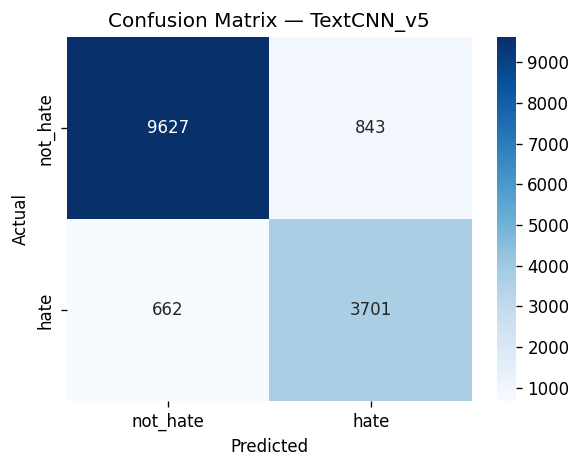

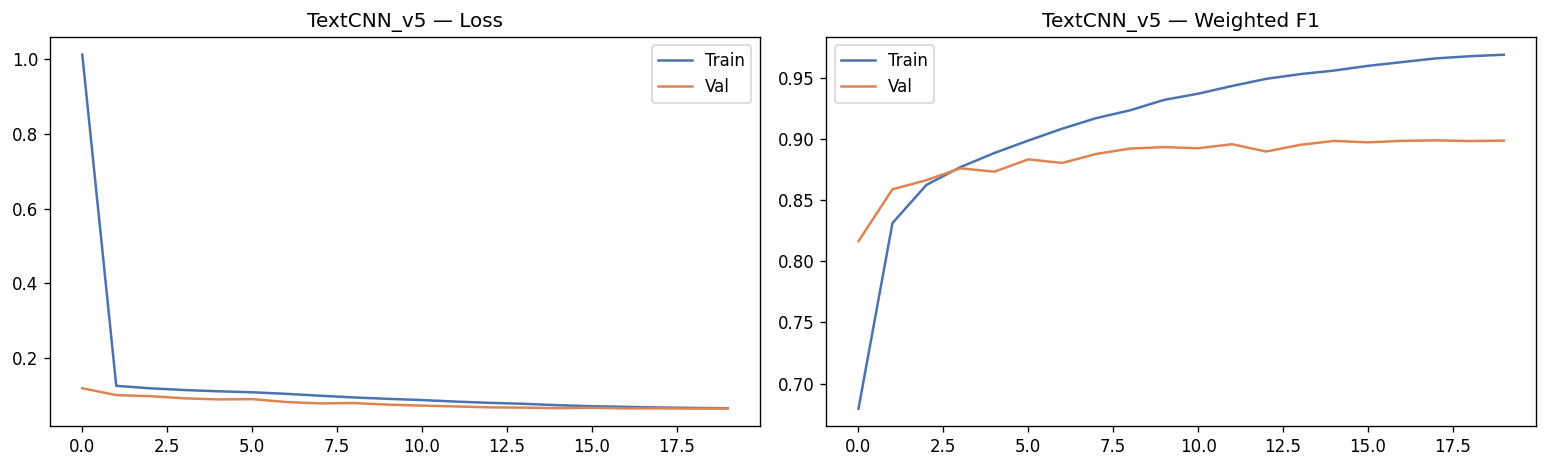

In [14]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 num_filters=256, filter_sizes=(2, 3, 4, 5),
                 num_classes=2, pad_idx=PAD_IDX, dropout=0.6):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convs      = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, fs)
                                         for fs in filter_sizes])
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(num_filters * len(filter_sizes))
        self.fc1 = nn.Linear(num_filters * len(filter_sizes), 128)
        self.fc2 = nn.Linear(128, num_classes)
        for conv in self.convs: nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)

    def forward(self, x):
        emb    = self.embedding(x).permute(0, 2, 1)
        pooled = [F.adaptive_max_pool1d(F.relu(conv(emb)), 1).squeeze(2) for conv in self.convs]
        out    = torch.cat(pooled, dim=1)
        out    = self.layer_norm(out)
        out    = self.dropout(out)
        out    = F.relu(self.fc1(out))
        out    = self.dropout(out)
        return self.fc2(out)


model_cnn = TextCNN()
load_pretrained_embedding(model_cnn.embedding, embed_matrix, freeze=True)

history_cnn, ckpt_cnn, _ = train_model_v4(
    model_cnn, train_loader, val_loader, 'TextCNN_v5',
    max_epochs=20, lr=1e-3, patience=5, mode='word', rdrop_alpha=4.0
)
model_cnn.load_state_dict(torch.load(ckpt_cnn, map_location=DEVICE))
crit = FocalLoss(gamma=2.0, class_weights=make_class_weights(y_train), label_smoothing=0.08)
_, _, y_pred_cnn, _, probs_cnn = evaluate_model(model_cnn, test_loader, crit, 'word')
_, _, _, _, val_probs_cnn = evaluate_model(model_cnn, val_loader, crit, 'word')
t_opt_cnn, _ = find_optimal_threshold(val_probs_cnn, y_val)
y_pred_cnn_t = (probs_cnn[:, 1] >= t_opt_cnn).astype(int)
print(f'Optimal threshold (val): {t_opt_cnn:.2f}')
evaluate_predictions(y_test, y_pred_cnn_t, 'TextCNN_v5')
plot_confusion_matrix(y_test, y_pred_cnn_t, 'TextCNN_v5')
plot_training_curves(history_cnn, 'TextCNN_v5')


## 9. BiGRU + Masked Attention (frozen embeddings + R-Drop)

  [fastText] Embedding FROZEN: (34043, 300)
  Class weights: {0: np.float64(0.588), 1: np.float64(1.412)}
Ep 01/20 | tr_f1=0.6823 va_f1=0.8462 | lr=5.00e-04 | 17.0s ← best
Ep 02/20 | tr_f1=0.8450 va_f1=0.8695 | lr=1.00e-03 | 14.1s ← best
Ep 03/20 | tr_f1=0.8589 va_f1=0.8774 | lr=9.44e-04 | 14.0s ← best
Ep 04/20 | tr_f1=0.8683 va_f1=0.8831 | lr=8.89e-04 | 14.0s ← best
Ep 05/20 | tr_f1=0.8740 va_f1=0.8818 | lr=8.33e-04 | 14.0s
Ep 06/20 | tr_f1=0.8808 va_f1=0.8774 | lr=7.78e-04 | 14.6s
Ep 07/20 | tr_f1=0.8826 va_f1=0.8930 | lr=7.22e-04 | 14.1s ← best
Ep 08/20 | tr_f1=0.8877 va_f1=0.8905 | lr=6.67e-04 | 14.0s
Ep 09/20 | tr_f1=0.8899 va_f1=0.8910 | lr=6.11e-04 | 13.8s
Ep 10/20 | tr_f1=0.8933 va_f1=0.8906 | lr=5.56e-04 | 13.5s
Ep 11/20 | tr_f1=0.8952 va_f1=0.8919 | lr=5.00e-04 | 13.7s
Ep 12/20 | tr_f1=0.8980 va_f1=0.8973 | lr=4.44e-04 | 13.9s ← best
Ep 13/20 | tr_f1=0.9014 va_f1=0.8961 | lr=3.89e-04 | 13.9s
Ep 14/20 | tr_f1=0.9022 va_f1=0.8952 | lr=3.33e-04 | 14.1s
Ep 15/20 | tr_f1=0.9055 va

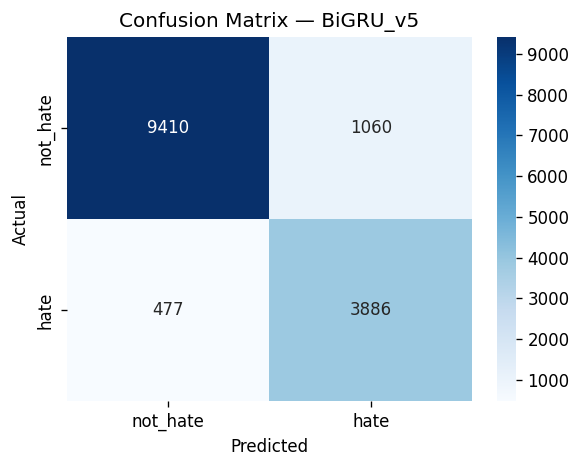

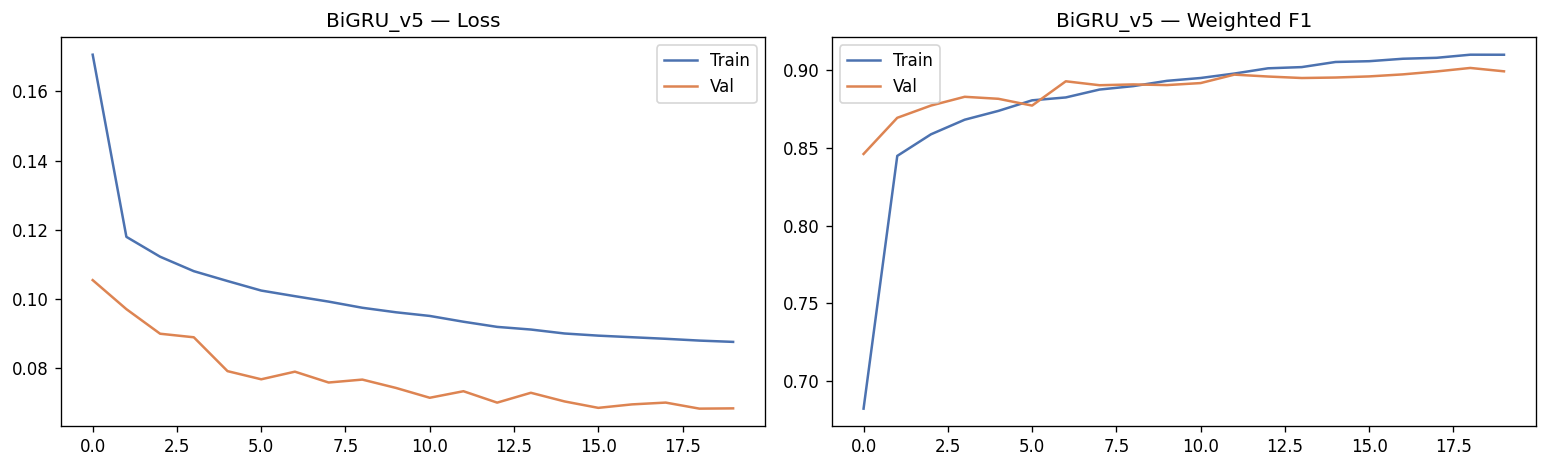

In [ ]:
class MaskedAdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, H, src_mask=None):
        scores = self.v(torch.tanh(self.attn(H))).squeeze(-1)
        if src_mask is not None:
            scores = scores.masked_fill(src_mask.bool().to(scores.device), float('-inf'))
        weights = F.softmax(scores, dim=1).unsqueeze(-1)
        return (H * weights).sum(dim=1)


class BiGRUAttention(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 hidden_dim=128, num_classes=2, pad_idx=PAD_IDX, dropout=0.5):
        super().__init__()
        self.pad_idx   = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.bigru     = nn.GRU(embed_dim, hidden_dim, batch_first=True,
                                bidirectional=True, num_layers=2, dropout=dropout)
        self.attention = MaskedAdditiveAttention(hidden_dim)
        self.dropout   = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        src_mask = (x == self.pad_idx)
        emb  = self.dropout(self.embedding(x))
        H, _ = self.bigru(emb)
        ctx  = self.attention(H, src_mask)
        ctx  = self.layer_norm(ctx)
        ctx  = self.dropout(ctx)
        out  = F.relu(self.fc1(ctx))
        out  = self.dropout(out)
        return self.fc2(out)


model_gru = BiGRUAttention()
load_pretrained_embedding(model_gru.embedding, embed_matrix, freeze=True)

history_gru, ckpt_gru, _ = train_model_v4(
    model_gru, train_loader, val_loader, 'BiGRU_v5',
    max_epochs=20, lr=1e-3, patience=5, mode='word', rdrop_alpha=4.0
)
model_gru.load_state_dict(torch.load(ckpt_gru, map_location=DEVICE))
crit = FocalLoss(gamma=2.0, class_weights=make_class_weights(y_train), label_smoothing=0.08)
_, _, y_pred_gru, _, probs_gru = evaluate_model(model_gru, test_loader, crit, 'word')
_, _, _, _, val_probs_gru = evaluate_model(model_gru, val_loader, crit, 'word')
t_opt_gru, _ = find_optimal_threshold(val_probs_gru, y_val)
y_pred_gru_t = (probs_gru[:, 1] >= t_opt_gru).astype(int)
print(f'Optimal threshold (val): {t_opt_gru:.2f}')
evaluate_predictions(y_test, y_pred_gru_t, 'BiGRU_v5')
plot_confusion_matrix(y_test, y_pred_gru_t, 'BiGRU_v5')
plot_training_curves(history_gru, 'BiGRU_v5')

## 10. CNN-BiGRU Hierarchical (frozen embeddings + R-Drop)

In [17]:
class CNNBiGRU_MT(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
                 num_filters=256, filter_sizes=(2, 3, 4),
                 gru_hidden=128, num_classes=2,
                 num_fine_classes=NUM_FINE_CLASSES,
                 pad_idx=PAD_IDX, dropout=0.5):
        super().__init__()
        self.pad_idx   = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout   = nn.Dropout(dropout)
        self.convs     = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, fs)
                                        for fs in filter_sizes])
        cnn_dim = num_filters * len(filter_sizes)
        self.bigru      = nn.GRU(embed_dim, gru_hidden, batch_first=True,
                                 bidirectional=True, num_layers=2, dropout=dropout)
        gru_dim = gru_hidden * 2
        self.attn_W     = nn.Linear(cnn_dim, gru_dim)
        combined_dim    = cnn_dim + gru_dim
        self.layer_norm = nn.LayerNorm(combined_dim)
        self.fc1        = nn.Linear(combined_dim, 128)
        self.main_head  = nn.Linear(128, num_classes)
        self.aux_head   = nn.Linear(128, num_fine_classes)
        for conv in self.convs: nn.init.kaiming_uniform_(conv.weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.fc1.weight)

    def forward(self, x_word, x_char=None):
        src_mask = (x_word == self.pad_idx)
        emb      = self.dropout(self.embedding(x_word))
        e_perm   = emb.permute(0, 2, 1)
        cnn_out  = torch.cat([F.adaptive_max_pool1d(F.relu(conv(e_perm)), 1).squeeze(2)
                               for conv in self.convs], dim=1)
        H, _     = self.bigru(emb)
        Q        = self.attn_W(cnn_out).unsqueeze(1)
        scores   = torch.bmm(Q, H.transpose(1, 2)).squeeze(1)
        # Fix: Use float('-inf') which is representable by torch.float16
        scores   = scores.masked_fill(src_mask.to(scores.device), float('-inf'))
        attn_ctx = (H * F.softmax(scores, dim=1).unsqueeze(-1)).sum(dim=1)
        combined = torch.cat([cnn_out, attn_ctx], dim=1)
        out      = self.layer_norm(combined)
        out      = self.dropout(out)
        feat     = F.relu(self.fc1(out))
        feat     = self.dropout(feat)
        return self.main_head(feat), self.aux_head(feat)


model_cgru = CNNBiGRU_MT()
load_pretrained_embedding(model_cgru.embedding, embed_matrix, freeze=True)

history_cgru, ckpt_cgru, _ = train_model_v4(
    model_cgru, dual_train_loader, dual_val_loader, 'CNNBiGRU_v5',
    max_epochs=20, lr=1e-3, patience=5, mode='dual', rdrop_alpha=4.0
)
model_cgru.load_state_dict(torch.load(ckpt_cgru, map_location=DEVICE))
crit = FocalLoss(gamma=2.0, class_weights=make_class_weights(y_train), label_smoothing=0.08)
_, _, y_pred_cgru, _, probs_cgru = evaluate_model(model_cgru, dual_test_loader, crit, 'dual')
_, _, _, _, val_probs_cgru = evaluate_model(model_cgru, dual_val_loader, crit, 'dual')
t_opt_cgru, _ = find_optimal_threshold(val_probs_cgru, y_val)
y_pred_cgru_t = (probs_cgru[:, 1] >= t_opt_cgru).astype(int)
print(f'Optimal threshold (val): {t_opt_cgru:.2f}')
evaluate_predictions(y_test, y_pred_cgru_t, 'CNNBiGRU_v5')
plot_confusion_matrix(y_test, y_pred_cgru_t, 'CNNBiGRU_v5')
plot_training_curves(history_cgru, 'CNNBiGRU_v5')

  [fastText] Embedding FROZEN: (34043, 300)
  Class weights: {0: np.float64(0.588), 1: np.float64(1.412)}


RuntimeError: value cannot be converted to type c10::Half without overflow

## 11. Transformer Experiment: MuRIL or TweetXLM-R

This is the core new experiment. The model is selected by `EXPERIMENT` in Section 1.

### Why layer freezing matters here
Both MuRIL and TweetXLM-R have already learned the relevant linguistic patterns
in their pre-training. Fine-tuning **all** layers on 90k noisy examples risks
overwriting those patterns (catastrophic forgetting).

- **Bottom 6 layers** - universal multilingual features (subword morphology,
  word order, basic syntax). **Freeze these.**
- **Top 6 layers** - task-specific abstractions. **Fine-tune these.**

### MuRIL-specific: why `max_len=128`
MuRIL was trained with a 512-token context window. Roman Urdu tweets are
short but MuRIL's tokeniser produces more subword tokens per word than XLM-R
because it has a dedicated South Asian subword vocabulary. 128 tokens captures
~95% of your data while fitting in T4 memory at batch_size=16.

### TweetXLM-R-specific: why `max_len=64`
This model was trained on tweets which average 20–30 tokens. Its positional
encodings are optimised for short sequences. 64 tokens matches its training
distribution and your data simultaneously.


In [ ]:
#  Build datasets 
print(f'Loading tokeniser: {CFG["model_name"]} ...')
trans_tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])

class TransformerDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.encodings.items()}, self.labels[i]

trans_train_ds = TransformerDataset(train_texts, y_train.tolist(), trans_tokenizer, CFG['max_len'])
trans_val_ds   = TransformerDataset(val_texts,   y_val.tolist(),   trans_tokenizer, CFG['max_len'])
trans_test_ds  = TransformerDataset(test_texts,  y_test.tolist(),  trans_tokenizer, CFG['max_len'])

trans_train_loader = DataLoader(trans_train_ds, batch_size=CFG['batch_train'], shuffle=True,  num_workers=2)
trans_val_loader   = DataLoader(trans_val_ds,   batch_size=CFG['batch_eval'],  shuffle=False, num_workers=2)
trans_test_loader  = DataLoader(trans_test_ds,  batch_size=CFG['batch_eval'],  shuffle=False, num_workers=2)

# Verify tokenisation on a few examples
sample_ids = trans_tokenizer(
    ['chutiya harami hai ye log', 'good morning dosto'],
    truncation=True, padding='max_length', max_length=CFG['max_len']
)['input_ids']
print('Sample token counts:', [len([t for t in ids if t != trans_tokenizer.pad_token_id])
                                for ids in sample_ids])
print(f'Datasets: train={len(trans_train_ds):,}  val={len(trans_val_ds):,}  test={len(trans_test_ds):,}')


Loading tokeniser: google/muril-base-cased ...


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Sample token counts: [9, 6]
Datasets: train=89,985  val=14,833  test=14,833


In [ ]:
# Load model & freeze bottom layers 
print(f'\nLoading model: {CFG["model_name"]} ...')
trans_model = AutoModelForSequenceClassification.from_pretrained(
    CFG['model_name'], num_labels=2
)

# Count parameters before freezing
total_params = sum(p.numel() for p in trans_model.parameters())

# Freeze embedding layer + bottom N transformer layers
n_freeze = CFG['freeze_layers']
for name, param in trans_model.named_parameters():
    if 'embeddings' in name:
        param.requires_grad = False
    elif any(f'encoder.layer.{i}.' in name for i in range(n_freeze)):
        param.requires_grad = False

frozen_params  = sum(p.numel() for p in trans_model.parameters() if not p.requires_grad)
train_params   = total_params - frozen_params

print(f'{CFG["display_name"]}: {total_params:,} total params')
print(f'  Frozen  : {frozen_params:,} ({frozen_params/total_params*100:.0f}%)')
print(f'  Training: {train_params:,} ({train_params/total_params*100:.0f}%)')

trans_model = trans_model.to(DEVICE)



Loading model: google/muril-base-cased ...


pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expe

MuRIL: 237,557,762 total params
  Frozen  : 194,438,400 (82%)
  Training: 43,119,362 (18%)


In [ ]:
#  Scheduler & optimiser 
trans_optimizer = AdamW(
    [p for p in trans_model.parameters() if p.requires_grad],
    lr=CFG['lr'], weight_decay=1e-2
)
trans_cw        = make_class_weights(y_train, device=DEVICE)
trans_criterion = nn.CrossEntropyLoss(weight=trans_cw, label_smoothing=CFG['label_smooth'])
trans_scaler    = GradScaler(enabled=(DEVICE.type == 'cuda'))

total_steps   = CFG['epochs'] * len(trans_train_loader)
warmup_steps  = int(CFG['warmup_frac'] * total_steps)
trans_scheduler = get_linear_warmup_decay_scheduler(trans_optimizer, warmup_steps, total_steps)

print(f'Warmup: {warmup_steps} steps | Total: {total_steps} steps')


  Class weights: {0: np.float64(0.588), 1: np.float64(1.412)}
Warmup: 4500 steps | Total: 45000 steps


In [ ]:
#  Training loop 
TRANS_CKPT  = f'./checkpoints/{CFG["display_name"]}_v5.pt'
trans_early = EarlyStopping(patience=CFG['patience'], mode='max')
best_trans_f1 = -np.inf
trans_history = defaultdict(list)
best_val_probs_trans = None

DISPLAY = CFG['display_name']
print(f'\nTraining {DISPLAY} (v5)')
print('=' * 60)
t_start = time.time()

for epoch in range(1, CFG['epochs'] + 1):
    t_ep = time.time()
    trans_model.train()
    tr_preds, tr_labels_list = [], []

    for enc, labels in trans_train_loader:
        trans_optimizer.zero_grad()
        enc    = {k: v.to(DEVICE) for k, v in enc.items()}
        labels = labels.to(DEVICE)

        with autocast(enabled=(DEVICE.type == 'cuda')):
            out1 = trans_model(**enc)    # first pass
            out2 = trans_model(**enc)    # second pass (R-Drop)
            loss = rdrop_loss(out1.logits, out2.logits, labels,
                              trans_criterion, alpha=CFG['rdrop_alpha'])

        trans_scaler.scale(loss).backward()
        trans_scaler.unscale_(trans_optimizer)
        nn.utils.clip_grad_norm_(trans_model.parameters(), 1.0)
        trans_scaler.step(trans_optimizer)
        trans_scaler.update()
        trans_scheduler.step()

        tr_preds.extend(out1.logits.argmax(1).cpu().numpy())
        tr_labels_list.extend(labels.cpu().numpy())

    tr_f1 = f1_score(tr_labels_list, tr_preds, average='weighted', zero_division=0)

    # Validation
    trans_model.eval()
    va_preds, va_labels_list, va_probs_list = [], [], []
    with torch.no_grad():
        for enc, labels in trans_val_loader:
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            with autocast(enabled=(DEVICE.type == 'cuda')):
                out = trans_model(**enc)
            va_preds.extend(out.logits.argmax(1).cpu().numpy())
            va_labels_list.extend(labels.numpy())
            va_probs_list.extend(F.softmax(out.logits, dim=1).cpu().numpy())

    va_f1 = f1_score(va_labels_list, va_preds, average='weighted', zero_division=0)
    trans_history['train_f1'].append(tr_f1)
    trans_history['val_f1'].append(va_f1)
    trans_history['train_loss'].append(0.0)   # placeholder
    trans_history['val_loss'].append(0.0)

    if va_f1 > best_trans_f1:
        best_trans_f1 = va_f1
        torch.save(trans_model.state_dict(), TRANS_CKPT)
        best_val_probs_trans = np.array(va_probs_list)

    trans_early(va_f1)
    cur_lr = trans_optimizer.param_groups[0]['lr']
    marker = ' ← best' if va_f1 == best_trans_f1 else ''
    print(f'Ep {epoch} | tr_f1={tr_f1:.4f} va_f1={va_f1:.4f} | '
          f'lr={cur_lr:.2e} | {time.time()-t_ep:.0f}s{marker}')
    if trans_early.stop:
        print('Early stopping.')
        break

print(f'\nTotal: {(time.time()-t_start)/60:.1f} min | Best val F1: {best_trans_f1:.4f}')



Training MuRIL (v5)
Ep 1 | tr_f1=0.8861 va_f1=0.8874 | lr=1.68e-05 | 858s ← best
Ep 2 | tr_f1=0.9140 va_f1=0.9124 | lr=1.41e-05 | 855s ← best
Ep 3 | tr_f1=0.9291 va_f1=0.9122 | lr=1.13e-05 | 829s
Ep 4 | tr_f1=0.9405 va_f1=0.9161 | lr=8.50e-06 | 832s ← best
Ep 5 | tr_f1=0.9493 va_f1=0.9189 | lr=5.72e-06 | 849s ← best
Ep 6 | tr_f1=0.9557 va_f1=0.9193 | lr=2.94e-06 | 832s ← best
Ep 7 | tr_f1=0.9598 va_f1=0.9198 | lr=1.63e-07 | 844s ← best
Ep 8 | tr_f1=0.9605 va_f1=0.9197 | lr=0.00e+00 | 836s

Total: 112.3 min | Best val F1: 0.9198


Optimal threshold (val): 0.50

=== MuRIL_v5 ===
  accuracy          : 0.9172
  f1_weighted       : 0.9177
  f1_hate           : 0.8622
  f1_not_hate       : 0.9408
  precision         : 0.9185
  recall            : 0.9172
              precision    recall  f1-score   support

    not_hate       0.95      0.93      0.94     10470
        hate       0.84      0.88      0.86      4363

    accuracy                           0.92     14833
   macro avg       0.90      0.91      0.90     14833
weighted avg       0.92      0.92      0.92     14833



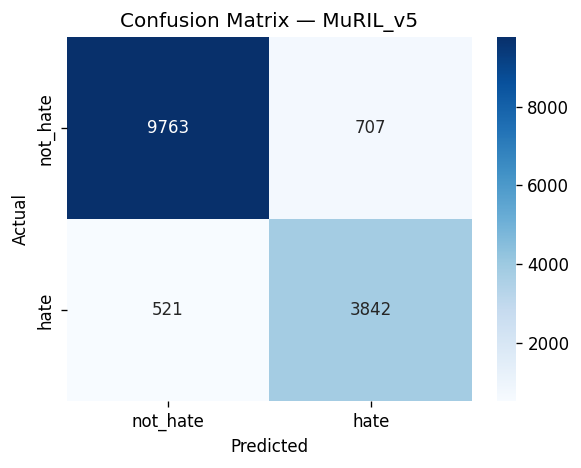

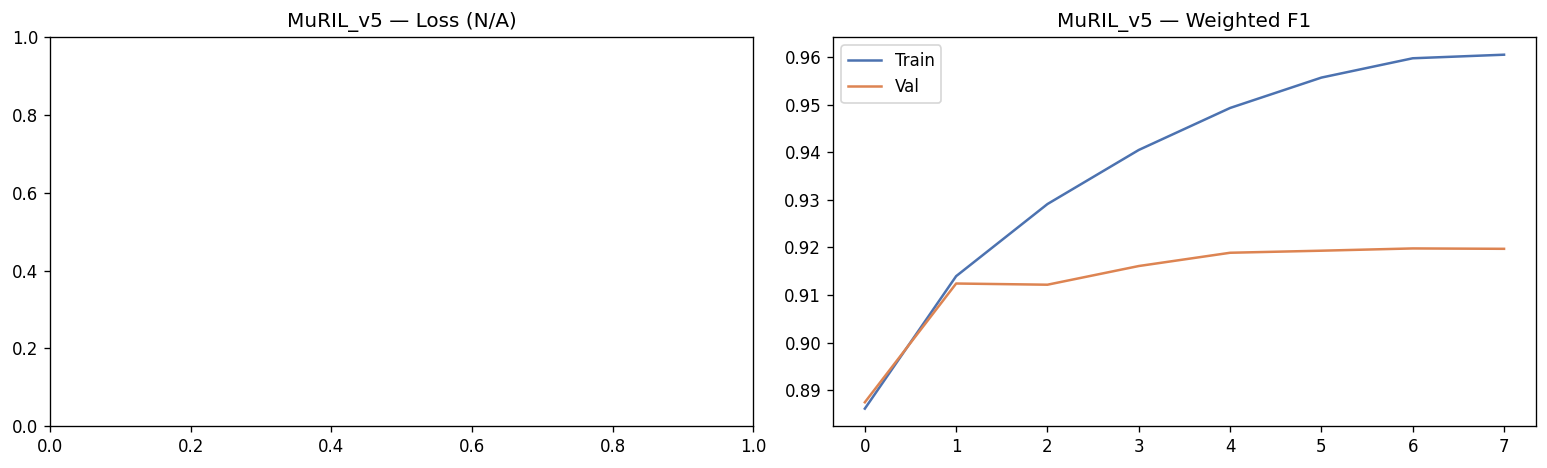

In [ ]:
#  Evaluate on test set 
t_opt_trans, _ = find_optimal_threshold(best_val_probs_trans, y_val)
print(f'Optimal threshold (val): {t_opt_trans:.2f}')

trans_model.load_state_dict(torch.load(TRANS_CKPT, map_location=DEVICE))
trans_model.eval()
all_trans_probs = []
with torch.no_grad():
    for enc, _ in trans_test_loader:
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with autocast(enabled=(DEVICE.type == 'cuda')):
            out = trans_model(**enc)
        all_trans_probs.extend(F.softmax(out.logits, dim=1).cpu().numpy())

probs_trans  = np.array(all_trans_probs)
y_pred_trans = (probs_trans[:, 1] >= t_opt_trans).astype(int)

evaluate_predictions(y_test, y_pred_trans, f'{DISPLAY}_v5')
plot_confusion_matrix(y_test, y_pred_trans, f'{DISPLAY}_v5')
plot_training_curves(dict(trans_history), f'{DISPLAY}_v5')


## 12. Final Ensemble: Transformer + BiGRU + CNNBiGRU

Uses learnable temperatures and weights fitted on the validation set.



In [ ]:
def get_logits_nn(model, loader, mode='word'):
    model.eval()
    all_logits = []
    with torch.no_grad():
        for batch in loader:
            if mode == 'word':
                x, _ = [b.to(DEVICE) for b in batch]
                logits = model(x)
            else:
                x, xc, _, _ = [b.to(DEVICE) for b in batch]
                logits, _ = model(x, xc)
            all_logits.append(logits.cpu())
    return torch.cat(all_logits, dim=0)


class LearnedEnsemble(nn.Module):
    def __init__(self, n_models):
        super().__init__()
        self.temperatures = nn.Parameter(torch.ones(n_models))
        self.raw_weights  = nn.Parameter(torch.zeros(n_models))

    def forward(self, logits_list):
        weights = F.softmax(self.raw_weights, dim=0)
        probs   = [F.softmax(l / self.temperatures[i].clamp(0.1, 10.0), dim=1)
                   for i, l in enumerate(logits_list)]
        return sum(w * p for w, p in zip(weights, probs))


# Collect val logits 
print('Collecting validation logits ...')
val_logits_gru  = get_logits_nn(model_gru,  val_loader,      mode='word')
val_logits_cgru = get_logits_nn(model_cgru, dual_val_loader, mode='dual')

# Transformer val logits
trans_model.eval()
trans_val_logits_list = []
with torch.no_grad():
    for enc, _ in trans_val_loader:
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with autocast(enabled=(DEVICE.type == 'cuda')):
            out = trans_model(**enc)
        trans_val_logits_list.append(out.logits.cpu())
val_logits_trans = torch.cat(trans_val_logits_list, dim=0)

val_logits_list = [val_logits_gru, val_logits_cgru, val_logits_trans]
y_val_tensor    = torch.tensor(y_val, dtype=torch.long)

#  Fit ensemble on val 
ensemble     = LearnedEnsemble(n_models=3)
ens_opt      = torch.optim.Adam(ensemble.parameters(), lr=0.01)
ens_crit     = nn.CrossEntropyLoss()

print('Fitting ensemble on validation set ...')
ensemble.train()
for step in range(100):
    ens_opt.zero_grad()
    probs = ensemble(val_logits_list)
    loss  = ens_crit(torch.log(probs + 1e-9), y_val_tensor)
    loss.backward(); ens_opt.step()
    if (step + 1) % 20 == 0:
        with torch.no_grad():
            preds = probs.argmax(1).numpy()
            f1    = f1_score(y_val, preds, average='weighted')
        print(f'  Step {step+1} | loss={loss.item():.4f} | val_f1={f1:.4f}')

ensemble.eval()
final_weights = F.softmax(ensemble.raw_weights, dim=0).detach().numpy()
final_temps   = ensemble.temperatures.detach().clamp(0.1, 10.0).numpy()
model_labels  = [f'BiGRU', f'CNNBiGRU', DISPLAY]
for name, w, t in zip(model_labels, final_weights, final_temps):
    print(f'  {name}: weight={w:.3f}  temperature={t:.3f}')


Fitting ensemble on validation set ...
  Step 20 | loss=0.4113 | val_f1=0.9195
  Step 40 | loss=0.3434 | val_f1=0.9201
  Step 60 | loss=0.2855 | val_f1=0.9202
  Step 80 | loss=0.2516 | val_f1=0.9207
  Step 100 | loss=0.2441 | val_f1=0.9206
  BiGRU: weight=0.444  temperature=0.149
  CNNBiGRU: weight=0.102  temperature=1.637
  MuRIL: weight=0.455  temperature=0.391



Optimal ensemble threshold: 0.50

=== Ensemble_v5_MuRILBiGRUCNN ===
  accuracy          : 0.9179
  f1_weighted       : 0.9187
  f1_hate           : 0.8656
  f1_not_hate       : 0.9409
  precision         : 0.9207
  recall            : 0.9179
              precision    recall  f1-score   support

    not_hate       0.96      0.93      0.94     10470
        hate       0.83      0.90      0.87      4363

    accuracy                           0.92     14833
   macro avg       0.90      0.91      0.90     14833
weighted avg       0.92      0.92      0.92     14833



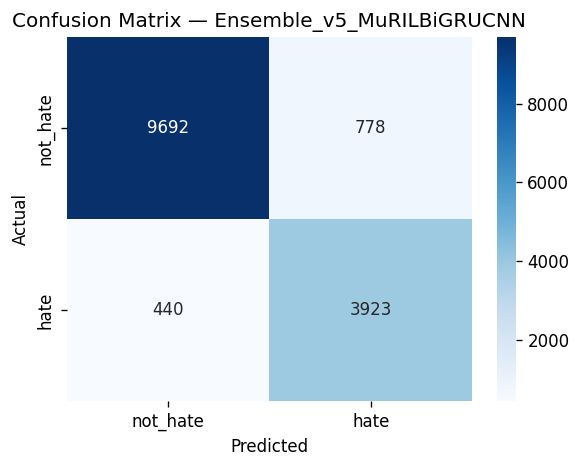

In [ ]:
# Test ensemble 
print('\nCollecting test logits ...')
test_logits_gru  = get_logits_nn(model_gru,  test_loader,      mode='word')
test_logits_cgru = get_logits_nn(model_cgru, dual_test_loader, mode='dual')

trans_model.eval()
trans_test_logits_list = []
with torch.no_grad():
    for enc, _ in trans_test_loader:
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with autocast(enabled=(DEVICE.type == 'cuda')):
            out = trans_model(**enc)
        trans_test_logits_list.append(out.logits.cpu())
test_logits_trans = torch.cat(trans_test_logits_list, dim=0)
test_logits_list  = [test_logits_gru, test_logits_cgru, test_logits_trans]

# Threshold on ensemble val probs
with torch.no_grad():
    ens_val_probs = ensemble(val_logits_list).numpy()
t_opt_ens, _ = find_optimal_threshold(ens_val_probs, y_val)
print(f'Optimal ensemble threshold: {t_opt_ens:.2f}')

with torch.no_grad():
    ens_test_probs = ensemble(test_logits_list).numpy()
y_pred_ens = (ens_test_probs[:, 1] >= t_opt_ens).astype(int)

ENS_NAME = f'Ensemble_v5_{DISPLAY}BiGRUCNN'
evaluate_predictions(y_test, y_pred_ens, ENS_NAME)
plot_confusion_matrix(y_test, y_pred_ens, ENS_NAME)


## 13. Final Results & Comparison


=== FINAL TEST RESULTS (v5) ===
                           Accuracy  F1 (weighted)  F1 (hate)  F1 (not_hate)  Precision  Recall
Model                                                                                          
LR+TFIDF                     0.8949         0.8959     0.8271         0.9245     0.8976  0.8949
SVM+TFIDF                    0.8931         0.8938     0.8225         0.9235     0.8949  0.8931
TextCNN_v5                   0.8985         0.8991     0.8310         0.9275     0.9000  0.8985
BiGRU_v5                     0.8964         0.8981     0.8349         0.9245     0.9029  0.8964
MuRIL_v5                     0.9172         0.9177     0.8622         0.9408     0.9185  0.9172
Ensemble_v5_MuRILBiGRUCNN    0.9179         0.9187     0.8656         0.9409     0.9207  0.9179


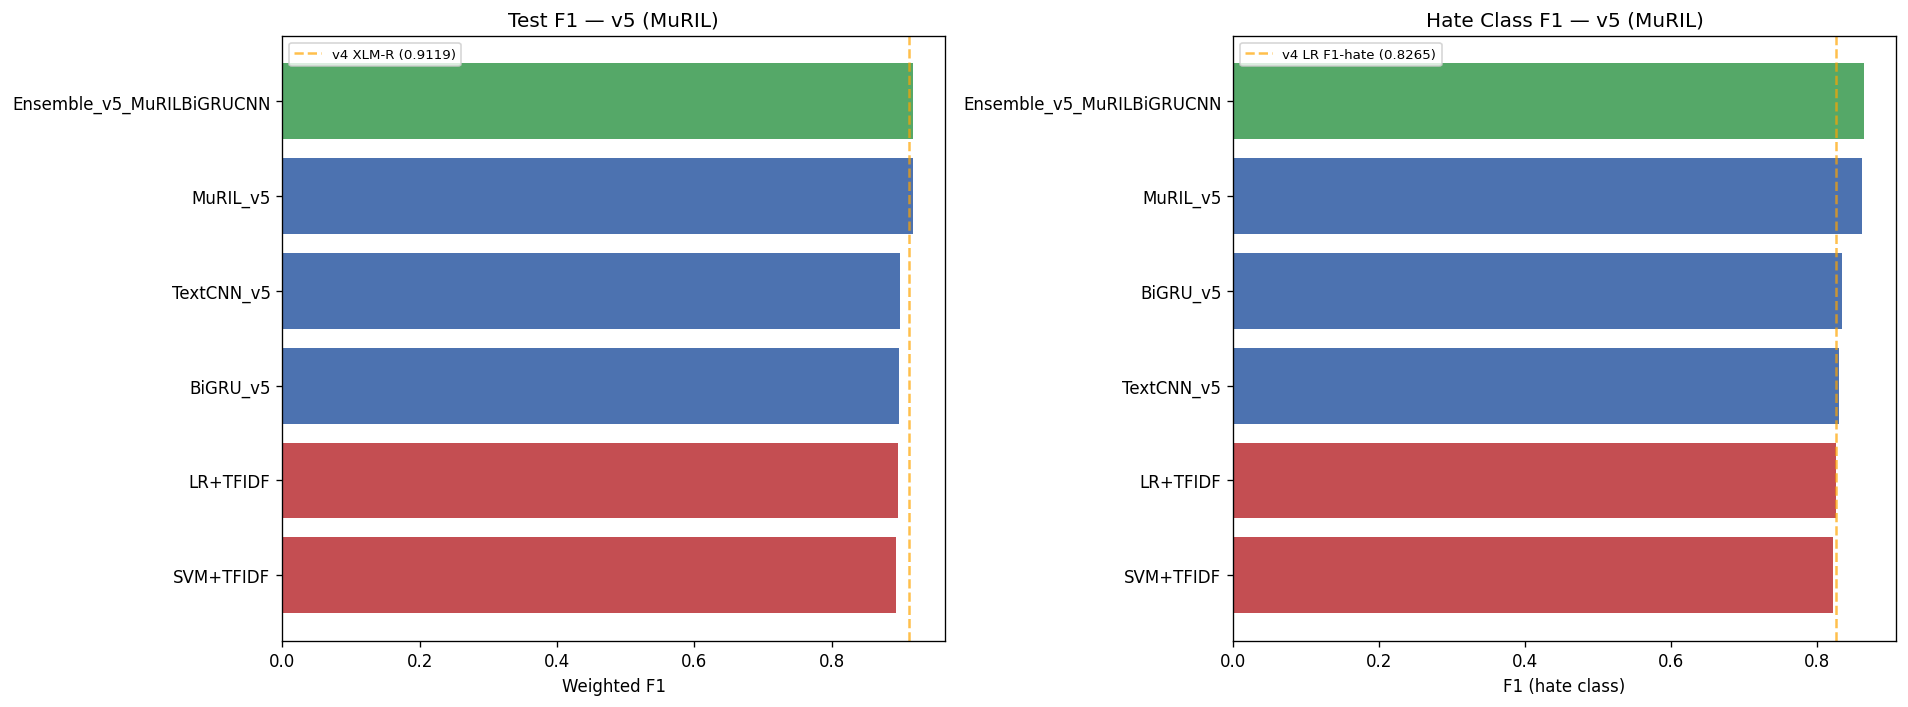

In [ ]:
rows = []
for name, m in ALL_RESULTS.items():
    rows.append({
        'Model':         name,
        'Accuracy':      m['accuracy'],
        'F1 (weighted)': m['f1_weighted'],
        'F1 (hate)':     m['f1_hate'],
        'F1 (not_hate)': m['f1_not_hate'],
        'Precision':     m['precision'],
        'Recall':        m['recall'],
    })

df_results = pd.DataFrame(rows).set_index('Model')
print('\n=== FINAL TEST RESULTS (v5) ===')
print(df_results.to_string())
df_results.to_csv(f'./results/final_results_v5_{EXPERIMENT}.csv')

#  Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot = df_results[['F1 (weighted)']].dropna().sort_values('F1 (weighted)')
colors  = ['#C44E52' if 'TFIDF' in n else '#55A868' if 'Ensemble' in n else '#4C72B0'
           for n in df_plot.index]
axes[0].barh(df_plot.index, df_plot['F1 (weighted)'], color=colors)
axes[0].axvline(0.9119, color='orange', linestyle='--', alpha=0.7, label='v4 XLM-R (0.9119)')
axes[0].set_xlabel('Weighted F1')
axes[0].set_title(f'Test F1 — v5 ({DISPLAY})')
axes[0].legend(fontsize=8)

df_hate = df_results[['F1 (hate)']].dropna().sort_values('F1 (hate)')
colors2 = ['#C44E52' if 'TFIDF' in n else '#55A868' if 'Ensemble' in n else '#4C72B0'
            for n in df_hate.index]
axes[1].barh(df_hate.index, df_hate['F1 (hate)'], color=colors2)
axes[1].axvline(0.8265, color='orange', linestyle='--', alpha=0.7, label='v4 LR F1-hate (0.8265)')
axes[1].set_xlabel('F1 (hate class)')
axes[1].set_title(f'Hate Class F1 — v5 ({DISPLAY})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'./results/final_comparison_v5_{EXPERIMENT}.png', bbox_inches='tight')
plt.show()
